# Viktor prompt-complexity pipeline

One run, top to bottom: **build the dataset → embed the request text → train a head →
score the held-out split → map scores onto model cutoffs.** Nothing here needs a GPU or an
API key, and no raw prompt text or generated output is embedded in this notebook.

The prediction target is a transparent weak-supervision score, not measured model quality.
The raw export has no final model output, no usage, no timing and no quality label.

### What the pipeline guarantees

- Every JSONL request becomes exactly one ML example.
- Exact prefix-linked requests are reconstructed into chains, and exact, prefix-linked and
  semantic near-duplicate task openings stay inside a single split.
- Feature scaling, the ridge penalty, the MLP weights and the choice between heads are all
  fitted or selected on train/validation only.
- **The test split is scored once**, at the end, for the one selected configuration.
- Predictor inputs are system text, user text and deterministic text statistics. The logged
  model is audit metadata and never becomes a feature.

### Where the time goes

The corpus is ~49M characters, but little of it is new: the Viktor system prompt is
near-identical across requests, and `user_messages` is byte-for-byte the join that already
formed `user_prompt`. Section 4 exploits both, and section 7 measures what that buys.

In [1]:
import json
import statistics
import sys
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from model import accurate_config, fast_config, run_pipeline
from model.data import check_leakage, ensure_dataset, load_splits
from model.embed import build_chunk_plan, segment_texts
from model.evaluate import format_metrics_table, plot_results
from model.features import band_of

# fast_config()     -> static token-embedding lookup, whole notebook in seconds
# accurate_config() -> MiniLM transformer, ~2.5 min on first run, cached afterwards
CONFIG = fast_config()

print(f'root        {ROOT}')
print(f'encoder     {CONFIG.encoder}  ({CONFIG.encoder_name})')
print(f'chunking    {CONFIG.max_chunk_chars} chars, budgets '
      f'system={CONFIG.system_max_chunks} user={CONFIG.user_max_chunks}')
print(f'dataset     {CONFIG.dataset_dir}')
print(f'seed        {CONFIG.seed}')

root        /Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026
encoder     static  (sentence-transformers/static-retrieval-mrl-en-v1)
chunking    960 chars, budgets system=8 user=32
dataset     /Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_dataset
seed        42


## 1. Build features, targets, metadata, and splits

The split is deterministic: re-running with the same seed reproduces the same assignment, and
near-duplicate prompt clusters are assigned atomically. `ensure_dataset` skips the rebuild when
the files on disk already match this config's seed and ratios.

In [2]:
manifest = ensure_dataset(CONFIG)

summary_keys = [
    'request_count', 'trajectory_count', 'split_group_count',
    'split_request_counts', 'complexity_bands_by_split',
    'label_confidence_by_split',
]
{key: manifest[key] for key in summary_keys}

Reusing dataset at /Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_dataset


{'request_count': 1000,
 'trajectory_count': 1000,
 'split_group_count': 872,
 'split_request_counts': {'train': 700, 'validation': 150, 'test': 150},
 'complexity_bands_by_split': {'train': {'medium': 479, 'high': 218, 'low': 3},
  'validation': {'medium': 102, 'high': 47, 'low': 1},
  'test': {'medium': 104, 'high': 44, 'low': 2}},
 'label_confidence_by_split': {'train': {'high': 196, 'medium': 504},
  'validation': {'medium': 108, 'high': 42},
  'test': {'medium': 112, 'high': 38}}}

## 2. Verify alignment and leakage invariants

These checks deliberately fail if a request is duplicated, if input/target order differs, or if
a prompt group or trajectory appears in more than one split. They re-derive the guarantee rather
than reading it back out of the manifest.

In [3]:
splits = load_splits(CONFIG)
integrity = check_leakage(splits, manifest)

# The catalog sections further down read the older tuple layout.
datasets = {name: (split.inputs, split.targets, split.metadata) for name, split in splits.items()}

print('Verified: aligned files, unique requests, and zero group/trajectory leakage.')
integrity

Verified: aligned files, unique requests, and zero group/trajectory leakage.


{'requests': 1000,
 'split_groups': 872,
 'trajectories': 1000,
 'leaked_split_groups': 0,
 'leaked_trajectories': 0}

## 3. Inspect score and confidence distributions

Only scores and audit metadata are shown here; prompts are intentionally never printed.

In [4]:
for split, (_, targets, _) in datasets.items():
    scores = [row['complexity_score'] for row in targets]
    print({
        'split': split,
        'rows': len(scores),
        'score_min': round(min(scores), 2),
        'score_mean': round(sum(scores) / len(scores), 2),
        'score_max': round(max(scores), 2),
        'bands': dict(Counter(row['complexity_band'] for row in targets)),
        'confidence': dict(Counter(row['label_confidence'] for row in targets)),
    })

{'split': 'train', 'rows': 700, 'score_min': 27.22, 'score_mean': 64.98, 'score_max': 98.65, 'bands': {'medium': 479, 'high': 218, 'low': 3}, 'confidence': {'high': 196, 'medium': 504}}
{'split': 'validation', 'rows': 150, 'score_min': 31.09, 'score_mean': 66.22, 'score_max': 93.71, 'bands': {'medium': 102, 'high': 47, 'low': 1}, 'confidence': {'medium': 108, 'high': 42}}
{'split': 'test', 'rows': 150, 'score_min': 25.57, 'score_mean': 63.83, 'score_max': 93.2, 'bands': {'medium': 104, 'high': 44, 'low': 2}, 'confidence': {'medium': 112, 'high': 38}}


In [5]:
# Detect provider-schema extraction failures and inspect remaining family effects.
model_scores = defaultdict(list)
nonempty_zero_intrinsic = []
for inputs, targets, metadata in datasets.values():
    for model_input, target, audit in zip(inputs, targets, metadata):
        model_scores[audit['logged_model']].append(target['complexity_score'])
        if model_input['user_prompt'].strip() and target['intrinsic_complexity'] == 0:
            nonempty_zero_intrinsic.append(target['request_id'])
assert not nonempty_zero_intrinsic
for model, scores in sorted(model_scores.items(), key=lambda item: -len(item[1])):
    print({
        'model': model, 'rows': len(scores),
        'mean_score': round(statistics.mean(scores), 2),
        'median_score': round(statistics.median(scores), 2),
    })

{'model': 'claude-opus-5', 'rows': 331, 'mean_score': 63.84, 'median_score': 62.42}
{'model': 'claude-sonnet-5', 'rows': 281, 'mean_score': 65.91, 'median_score': 64.49}
{'model': 'gpt-5.6-terra', 'rows': 113, 'mean_score': 66.49, 'median_score': 66.1}
{'model': 'gpt-5.6-sol', 'rows': 112, 'mean_score': 65.99, 'median_score': 65.54}
{'model': 'claude-fable-5', 'rows': 71, 'mean_score': 65.08, 'median_score': 64.32}
{'model': 'claude-opus-4-8', 'rows': 69, 'mean_score': 61.76, 'median_score': 60.76}
{'model': 'gpt-5.6-luna', 'rows': 20, 'mean_score': 68.23, 'median_score': 66.95}
{'model': 'claude-opus-4-6', 'rows': 2, 'mean_score': 69.02, 'median_score': 69.02}
{'model': 'claude-sonnet-4-6', 'rows': 1, 'mean_score': 53.55, 'median_score': 53.55}


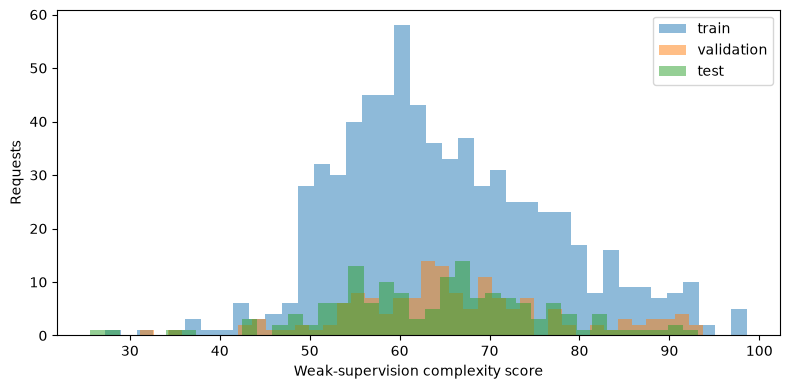

In [6]:
# Optional visualization; the data pipeline itself needs no third-party packages.
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('Install matplotlib to display the histogram.')
else:
    plt.figure(figsize=(8, 4))
    for split, (_, targets, _) in datasets.items():
        plt.hist(
            [row['complexity_score'] for row in targets],
            bins=40, alpha=0.5, label=split,
        )
    plt.xlabel('Weak-supervision complexity score')
    plt.ylabel('Requests')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Embed the request text

Each request is split into two segments — system prompt and user text — and each segment is
chunked, encoded and mean-pooled on its own, so the head can weight near-boilerplate system
text differently from the request-specific part.

Four choices decide how long this takes:

| choice | why |
|---|---|
| drop `user_messages` | it is exactly `"\n\n".join(...)` of the text already in `user_prompt`, so embedding it doubles the cost for zero new signal |
| pack chunks on paragraph boundaries | two prompts stay in phase for as long as they agree, so a shared prefix — most of what repeats here — collapses to shared chunks, as does any block too long to pack |
| encode each unique chunk once | the pooled result is scattered back to every row that referenced it |
| per-segment chunk budgets | bounds a pathologically long prompt by sampling across it, rather than truncating its tail away |

Paragraph packing is not a general alignment guarantee: two prompts that differ in length
*before* a shared run will still chunk that run differently. Content-defined chunk boundaries
were measured against this export and recovered nothing over the simpler rule, so the
deduplication figure below is close to what this corpus actually allows.

The pooled matrix is cached on disk under a hash of the settings *and* the chunk text, so a
re-run costs nothing and any settings change invalidates cleanly.

In [7]:
# What the plan looks like before anything is encoded.
all_rows = [row for name in ('train', 'validation', 'test') for row in splits[name].inputs]
plan = build_chunk_plan(all_rows, CONFIG)

raw_chars = sum(len(text) for row in all_rows for text in segment_texts(row).values())
redundant = sum(len(json.dumps(row.get('user_messages', []))) for row in all_rows)
stats = plan.stats()

print(f"rows                    {stats['rows']:>12,}")
print(f"chunks referenced       {stats['chunks_referenced']:>12,}")
print(f"chunks actually encoded {stats['chunks_encoded']:>12,}   "
      f"({stats['dedup_ratio']}x saved by deduplication)")
print(f"characters in segments  {raw_chars:>12,}")
print(f"characters encoded      {stats['chars_encoded']:>12,}")
print(f"characters skipped as redundant (user_messages) {redundant:>12,}")

rows                           1,000
chunks referenced             25,098
chunks actually encoded       19,689   (1.27x saved by deduplication)
characters in segments    48,177,884
characters encoded        14,640,694
characters skipped as redundant (user_messages)   12,785,282


## 5. Train the head

The encoder stays frozen; only a head is fitted on top of the pooled embeddings plus the eleven
deterministic text statistics. Three candidates are trained and compared on validation:

- **mean** — predict the training mean. The floor any real head has to clear.
- **ridge** — closed-form multi-output ridge. One economy SVD serves the whole penalty grid, so
  sweeping alphas costs a few vector operations instead of a refit per value.
- **mlp** — a small multi-task MLP over the same features, early-stopped on validation.

All three predict `complexity_score` alongside its two components; the components are auxiliary
supervision and the reported metric is always the score. `run_pipeline` selects the best head on
validation MAE and only then scores the test split.

In [8]:
report = run_pipeline(CONFIG)

print()
print(format_metrics_table(report['comparison'], (
    'variant', 'validation_MAE', 'validation_R2', 'validation_spearman',
    'validation_band_accuracy', 'fit_seconds',
)))
print(f"\nselected: {report['selected']}  {report['selected_detail']}")

Reusing dataset at /Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_dataset
Dataset: 1000 requests, 872 prompt groups, no split leakage ({'train': 700, 'validation': 150, 'test': 150})
Loaded cached embeddings all-static-3f7027d5ebeef2b5238c.npy (1000, 2048)
Features: 2059 dims (cached)
Selected head: ridge (validation MAE 4.556)
Test: MAE 4.508  R2 0.765  spearman 0.855  band acc 0.853
Wrote /Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/results/complexity_model/report.json

variant  validation_MAE  validation_R2  validation_spearman  validation_band_accuracy  fit_seconds
--------------------------------------------------------------------------------------------------
ridge    4.556           0.729          0.86                 0.827                     0.439      
mlp      4.681           0.714          0.858                0.847                     1.268      
mean     9.053           -0.011         0.0                  0.68       

## 6. Evaluate on the held-out split

`MAE` and `R2` measure the point estimate, but a router never consumes one — it compares a
request against a cutoff. `spearman` and `band_accuracy` are therefore reported alongside,
because a model can lose on MAE and still order requests correctly.

Read the per-band table with the band sizes in view. This workload is almost entirely
medium and high: the **low** band holds 3 of 700 training rows and 2 of 150 test rows, so its
error column is an anecdote, not a measurement. The model has essentially never been shown an
easy request, and nothing below should be read as evidence about how it handles one.

In [9]:
print(format_metrics_table(
    [{'split': name, **report[name]['metrics']} for name in ('train', 'validation', 'test')],
    ('split', 'n', 'MAE', 'RMSE', 'R2', 'pearson', 'spearman', 'band_accuracy'),
))

print('\nHeld-out test, per true band:')
print(format_metrics_table(report['test']['bands'],
                           ('band', 'n', 'share', 'MAE', 'mean_true', 'mean_pred', 'recall')))

print('\nBand confusion on test (rows = true, columns = predicted):')
print(format_metrics_table(
    [{'true': band, **counts} for band, counts in report['test']['confusion'].items()],
    ('true', 'low', 'medium', 'high'),
))

split       n    MAE    RMSE   R2     pearson  spearman  band_accuracy
----------------------------------------------------------------------
train       700  4.102  5.366  0.796  0.893    0.898     0.874        
validation  150  4.556  6.232  0.729  0.859    0.86      0.827        
test        150  4.508  5.72   0.765  0.881    0.855     0.853        

Held-out test, per true band:
band    n    share  MAE     mean_true  mean_pred  recall
--------------------------------------------------------
low     2    0.013  13.036  26.58      39.62      0.5   
medium  104  0.693  4.227   58.85      61.16      0.875 
high    44   0.293  4.784   77.31      74.12      0.818 

Band confusion on test (rows = true, columns = predicted):
true    low  medium  high
-------------------------
low     1    1       0   
medium  0    91      13  
high    0    8       36  


timings (s): {'dataset': 0.24, 'embedding': 0.23, 'training': 2.75}


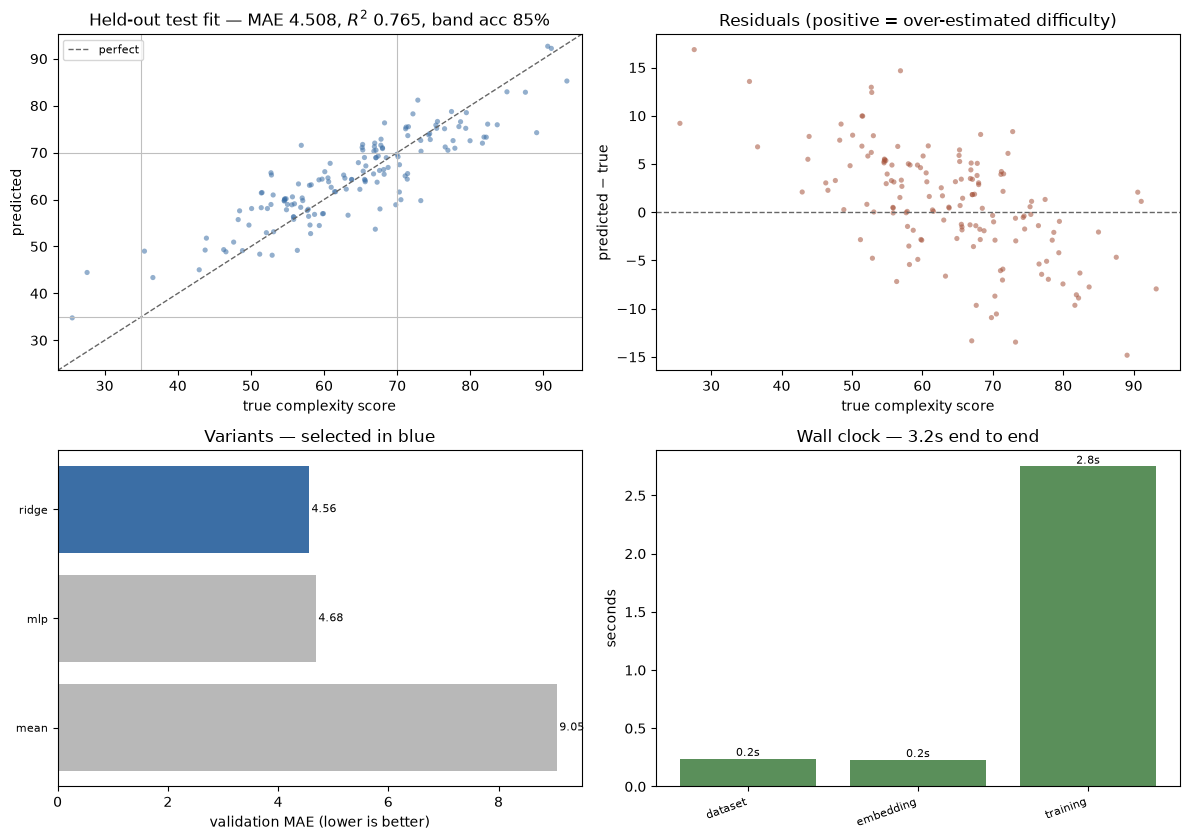

In [10]:
head = report['_head']
test_true = report['_targets']['test'][:, 0]
test_pred = head.predict(report['_features']['test'])[:, 0]

figure = plot_results(report, test_true, test_pred,
                      path=CONFIG.results_dir / 'complexity_model.png')
print(f"timings (s): {report['timings']}")

## 7. What each part of the input is worth, and what it costs

Every variant below is scored on **validation only** — the test split stays sealed, so this
comparison cannot quietly become test-set tuning.

The row worth reading twice is `features only`: eleven integer counts already reach most of the
way, because the intrinsic half of the target is a function of prompt text statistics. The
embeddings are earning their keep on the *observed* half — how much execution the request
turned out to need — which no character count can see.

`cold_encode_s` is what the encoder costs the first time; every later run reads the cached
matrix instead. That column is the reason `static` is the default: it gives up a little
accuracy against MiniLM and buys back roughly two orders of magnitude of encoding time.

Set `INCLUDE_MINILM = False` to skip the transformer variant; it costs ~2.5 minutes the first
time and nothing on later runs.

In [11]:
from model.benchmark import compare

INCLUDE_MINILM = True

variants = {
    'features only': fast_config(use_embeddings=False),
    'static embeddings only': fast_config(use_static_features=False),
    'static + features': fast_config(),
}
if INCLUDE_MINILM:
    variants['minilm + features'] = accurate_config()

benchmark = compare(variants, verbose=False)
print(format_metrics_table(benchmark, (
    'variant', 'encoder', 'dims', 'head', 'val_MAE', 'val_R2', 'val_spearman',
    'val_band_acc', 'encoded_chunks', 'chunks_per_s', 'cold_encode_s', 'train_s',
)))
print('\ncold_encode_s and chunks_per_s are measured on the first, uncached run and')
print('recorded alongside the cache, so a cache hit cannot make a slow encoder look free.')

variant                 encoder  dims  head   val_MAE  val_R2  val_spearman  val_band_acc  encoded_chunks  chunks_per_s  cold_encode_s  train_s
-----------------------------------------------------------------------------------------------------------------------------------------------
features only           —        11    mlp    4.967    0.689   0.829         0.84          0               0             0.0            0.12   
static embeddings only  static   2048  mlp    6.475    0.47    0.711         0.773         19689           6890          2.86           0.56   
static + features       static   2059  ridge  4.556    0.729   0.86          0.827         19689           6890          2.86           0.91   
minilm + features       minilm   779   ridge  4.473    0.751   0.873         0.867         19689           148           133.02         0.68   

cold_encode_s and chunks_per_s are measured on the first, uncached run and
recorded alongside the cache, so a cache hit cannot make a s

## 8. Experimental model catalog — unverified assumptions only

Sections 1–6 produce a 0–100 complexity score per request. A router needs the other half of
the mapping: for each candidate model, the complexity above which it should not be trusted.
`scripts/model_catalog.py` demonstrates how assumed benchmark results could be mapped to
cutoffs. Its bundled cards and tier order are not verified evidence.

**The model ids are anonymized.** The bundled identity mapping, benchmark values, sources,
tier order, and `scripts/pricing.json` are assumptions unless the organizers explicitly
verify them. Do not use this section as submission evidence without approved replacements.

The chain is kept short so each link can be argued with:

| step | what it does |
|---|---|
| benchmark panel | five agentic benchmarks, weighted by how well each proxies *this* workload |
| additive fit | joint model-ability / benchmark-difficulty estimate, on the logit scale |
| spread | rescale fitted ability across the catalog to 0–1 |
| quantile | map onto `[quantile_floor, 1]`, minus a margin that grows as evidence thins |
| cutoff | read that quantile off the **observed training** complexity distribution |

A benchmark score says nothing about this dataset's 0–100 scale, so the fit is used only to
**order and space** the models; the thresholds themselves come from the empirical
distribution. Calibration uses the training split only — calibrating on validation or test
would leak the evaluation set into the router, the invariant sections 1–2 exist to protect.

In [12]:
import importlib
import sys

if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))
import model_catalog

importlib.reload(model_catalog)

train_scores = [row['complexity_score'] for row in datasets['train'][1]]
catalog = model_catalog.build_catalog(train_scores, risk_aversion=0.10)

print(f"calibrated on {catalog['calibrated_on']['n_requests']} training requests "
      f"(scores {catalog['calibrated_on']['score_min']}–{catalog['calibrated_on']['score_max']})")
print(f"frontier / routing fallback: {catalog['frontier_model']}")
print(f"detectability band: {catalog['tie_band']:.2f} score points\n")

header = (f"{'model':<20}{'tier':>5}{'fitted':>9}{'evidence':>10}{'benchmarks':>12}"
          f"{'cutoff':>8}   indistinguishable from")
print(header)
print('-' * (len(header) + 20))
for entry in catalog['models']:
    peers = ', '.join(entry['indistinguishable_from']) or '—'
    flag = '*' if entry['is_frontier'] else ('~' if entry['imputed'] else ' ')
    print(f"{entry['model_id']:<20}{entry['tier_group']:>5}"
          f"{entry['expected_score']:>9.2f}{entry['evidence_coverage']:>9.0%}"
          f"{entry['n_benchmarks']:>12}{entry['complexity_cutoff']:>8.2f} {flag} {peers}")
print('\n* frontier (used when nothing else covers a request)   ~ imputed, no public evidence')
print('evidence = share of the weighted benchmark panel this model actually has results for')
print('Selection is capability-only. Prices are recorded on each model card but are never')
print('consulted when ranking or routing, so no cost objective enters this evaluation.')

calibrated on 700 training requests (scores 27.22–98.65)
frontier / routing fallback: gpt-5.6-sol
detectability band: 2.67 score points

model                tier   fitted  evidence  benchmarks  cutoff   indistinguishable from
-------------------------------------------------------------------------------------------------------------
gpt-5.6-sol             1    83.74      87%           4   86.41 * gpt-5.6-terra, claude-fable-5, claude-opus-5, gpt-5.6-luna
gpt-5.6-terra           1    83.74      65%           3   85.48   gpt-5.6-sol, claude-fable-5, claude-opus-5, gpt-5.6-luna
claude-fable-5          1    82.72     100%           5   82.85   gpt-5.6-sol, gpt-5.6-terra, claude-opus-5, gpt-5.6-luna
claude-opus-5           1    81.64      53%           2   77.50   gpt-5.6-sol, gpt-5.6-terra, claude-fable-5, gpt-5.6-luna
gpt-5.6-luna            1    81.13      65%           3   76.63   gpt-5.6-sol, gpt-5.6-terra, claude-fable-5, claude-opus-5
claude-sonnet-5         2    74.86      62%   

### 8.1 Which capability differences are real

Coverage in the bundled assumption panel is ragged — Opus 5 has no assumed SWE-bench Pro
result, the GPT-5.6 tiers have no SWE-bench Verified, `claude-opus-4-6` has nothing at all —
and the benchmarks also **disagree systematically about which family is stronger**. Those are
two different problems and they need two different fixes.

*Ragged coverage.* A naive composite (`score / best observed score`, averaged over whatever a
model happens to have) compares models on incomparable panels, so being measured only where
your family is strong is rewarded. Fix: compare every pair of models **only on the benchmarks
both were measured on**, then reconcile those pairwise differences into one ability by
weighted least squares.

*Systematic disagreement.* Least squares is still a global fit, so a model can be dragged down
through third parties. This is not hypothetical — it produced a live bug in an earlier version
of this notebook:

> `gpt-5.6-terra` was ranked **above** `gpt-5.6-sol`, even though Sol beats Terra on all three
> benchmarks they share (88.8 vs 87.4, 80.0 vs 77.4, 53.6 vs 50.4). The cause: Sol is unusually
> weak on SWE-bench Pro — 12 points below its own fit, the largest residual in the panel — and
> Terra was never measured on it. The penalty reached Terra's rival through models Terra never
> met.

Fix: **direct evidence outranks indirect inference.** Abilities are projected onto the partial
order of head-to-head dominance — if A beat B on every benchmark they share, A may not rank
below B — pooling any violating pair until none remain. Pooling equalises rather than
reorders, which is the smallest correction that removes the false claim.

Two things worth checking below: that the fitted difficulties rank **SWE-bench Verified as the
easiest** benchmark (everyone scores 88–97 on it) and **Agents' Last Exam as the hardest**; and
the **detectability band** from the fit's own residuals — the smallest gap in fitted score
worth believing.

In [13]:
cards = model_catalog._catalog_cards()
fit = model_catalog.fit_capability(cards)

print('fitted benchmark difficulty (logit; higher = everyone scores well = easier):')
for name, value in sorted(fit['difficulty'].items(), key=lambda kv: -kv[1]):
    print(f"  {model_catalog.BENCHMARKS[name]['label']:<24}{value:+7.3f}"
          f"   weight {model_catalog.BENCHMARKS[name]['weight']:.2f}")

print('\nhead-to-head dominance (A scored higher on every benchmark A and B both have):')
for winner, loser, shared in model_catalog.dominance_pairs(cards):
    print(f"  {winner:<20} > {loser:<20} on {shared} shared benchmarks")

repairs = fit['dominance_repaired']
print(f"\ndominance repairs applied: {len(repairs)}")
for repair in repairs:
    print(f"  {repair['winner']} had been ranked below {repair['loser']}"
          f"  ->  pooled {', '.join(repair['pooled_members'])}")
violations = [(w, l) for w, l, _ in model_catalog.dominance_pairs(cards)
              if fit['models'][w]['ability'] < fit['models'][l]['ability'] - 1e-12]
print(f"violations remaining after repair: {len(violations)}")

print('\nnaive composite vs fitted ability (rank shown as naive -> fitted):')
naive = model_catalog.naive_composite(cards)
naive_rank = {m: i + 1 for i, m in enumerate(
    sorted((k for k, v in naive.items() if v is not None), key=lambda k: -naive[k]))}
fit_rank = {m['model_id']: i + 1 for i, m in enumerate(catalog['models'])}

print(f"  {'model':<20}{'naive':>8}{'fitted':>8}{'rank':>10}{'benchmarks':>12}")
for entry in catalog['models']:
    mid = entry['model_id']
    value = naive.get(mid)
    moved = f"{naive_rank.get(mid, '-')} -> {fit_rank[mid]}"
    print(f"  {mid:<20}{'n/a' if value is None else f'{value:.3f}':>8}"
          f"{entry['expected_score']:>8.2f}{moved:>10}{entry['n_benchmarks']:>12}")

print(f"\nDetectability band: {catalog['tie_band']:.2f} score points.")
for tier in sorted({e['tier_group'] for e in catalog['models']}):
    members = [e for e in catalog['models'] if e['tier_group'] == tier]
    span = max(m['expected_score'] for m in members) - min(m['expected_score'] for m in members)
    print(f"  tier {tier}: {', '.join(m['model_id'] for m in members)}")
    print(f"          fitted spread {span:.2f} pts "
          f"| members are interchangeable for routing")

fitted benchmark difficulty (logit; higher = everyone scores well = easier):
  SWE-bench Verified       +1.511   weight 0.13
  Terminal-Bench 2.1       +0.269   weight 0.40
  AA Coding Agent Index    -0.347   weight 0.15
  SWE-bench Pro            -0.405   weight 0.22
  Agents' Last Exam        -1.629   weight 0.10

head-to-head dominance (A scored higher on every benchmark A and B both have):
  claude-fable-5       > claude-opus-4-8      on 3 shared benchmarks
  claude-fable-5       > claude-sonnet-5      on 2 shared benchmarks
  claude-fable-5       > claude-sonnet-4-6    on 2 shared benchmarks
  claude-opus-5        > claude-opus-4-8      on 2 shared benchmarks
  claude-opus-4-8      > claude-sonnet-4-6    on 2 shared benchmarks
  claude-sonnet-5      > claude-sonnet-4-6    on 2 shared benchmarks
  gpt-5.6-sol          > claude-sonnet-5      on 2 shared benchmarks
  gpt-5.6-sol          > claude-sonnet-4-6    on 2 shared benchmarks
  gpt-5.6-sol          > gpt-5.6-terra        on 3 

### 8.2 Cutoffs against the distribution they were calibrated on

The cutoffs only mean something relative to the complexity distribution they were read off.
Plotting them together shows how much of the observed workload each model is trusted with —
and makes it obvious when a cutoff sits somewhere the distribution is thin, where small
changes in the fit move a lot of traffic.

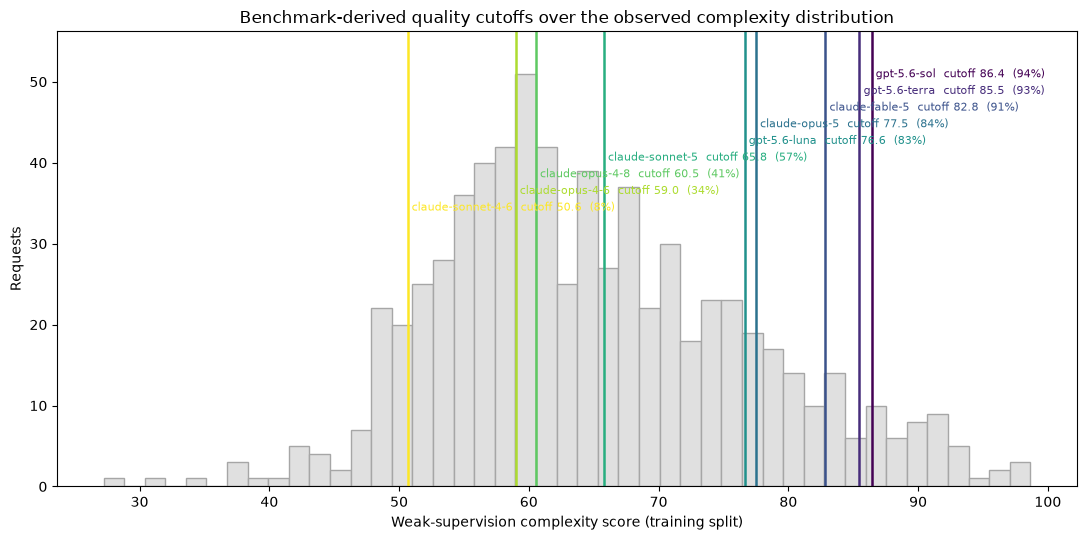

Percentage after each label = share of training requests at or below that cutoff.


In [14]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print('Install matplotlib to display the cutoff chart.')
    for entry in catalog['models']:
        share = sum(1 for s in train_scores if s <= entry['complexity_cutoff']) / len(train_scores)
        print(f"  {entry['model_id']:<20} cutoff {entry['complexity_cutoff']:>6.2f}"
              f"   trusted with {share:>6.1%} of training requests")
else:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.hist(train_scores, bins=45, color='0.88', edgecolor='0.65', label='training requests')
    top = ax.get_ylim()[1]
    ax.set_ylim(0, top * 1.05)
    colours = plt.cm.viridis(
        [i / max(len(catalog['models']) - 1, 1) for i in range(len(catalog['models']))])

    for position, (colour, entry) in enumerate(zip(colours, catalog['models'])):
        share = sum(1 for s in train_scores
                    if s <= entry['complexity_cutoff']) / len(train_scores)
        ax.axvline(entry['complexity_cutoff'], color=colour, linewidth=1.8)
        ax.annotate(
            f"{entry['model_id']}  cutoff {entry['complexity_cutoff']:.1f}  ({share:.0%})",
            xy=(entry['complexity_cutoff'], top),
            xytext=(3, -11 - 12 * position), textcoords='offset points',
            fontsize=8, color=colour, va='top',
        )

    ax.set_xlabel('Weak-supervision complexity score (training split)')
    ax.set_ylabel('Requests')
    ax.set_title('Benchmark-derived quality cutoffs over the observed complexity distribution')
    plt.tight_layout()
    plt.show()

    print('Percentage after each label = share of training requests at or below that cutoff.')

### 8.3 The logged policy is not complexity-aware — which is where the headroom is

Before trusting any cutoff, it is worth asking what the *logged* assignment already does. If
Viktor were routing by difficulty, hard requests would sit on strong models and the correlation
between a request's complexity and its serving model's fitted capability would be clearly
positive.

It is not. That single fact carries most of the routing argument in this notebook, and it cuts
two ways:

- **In favour of a router:** there is real headroom, because the current assignment leaves
  complexity on the table. Any complexity-aware policy is competing against a policy that
  ignores complexity.
- **Against over-claiming:** because the logged data contains almost no complexity-driven
  model assignment, it also contains almost no evidence about which model a hard request
  *needs*. The observational log can tell us the current policy is undifferentiated; it cannot
  tell us the cutoffs are correct.

In [15]:
import statistics


def pearson(xs, ys):
    mx, my = statistics.mean(xs), statistics.mean(ys)
    numerator = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    denominator = (sum((x - mx) ** 2 for x in xs) * sum((y - my) ** 2 for y in ys)) ** 0.5
    return numerator / denominator if denominator else 0.0


capability = {m['model_id']: m['expected_score'] for m in catalog['models']}

scores = [t['complexity_score'] for t in datasets['train'][1]]
served = [m['logged_model'] for m in datasets['train'][2]]

print(f"corr(complexity, fitted capability of the model that served it) = "
      f"{pearson(scores, [capability[m] for m in served]):+.3f}")

grouped = {}
for score, model in zip(scores, served):
    grouped.setdefault(model, []).append(score)

between = statistics.pstdev([statistics.mean(v) for v in grouped.values()])
within = statistics.mean([statistics.pstdev(v) for v in grouped.values() if len(v) > 1])
print(f"\nspread of per-model mean complexity : {between:>5.1f}")
print(f"typical spread *within* one model    : {within:>5.1f}")
print(f"overall complexity range             : {min(scores):.1f}–{max(scores):.1f}")
print('\nWithin-model variation swamps between-model variation: whatever decided which')
print('model served a request, it was almost entirely something other than difficulty.')

corr(complexity, fitted capability of the model that served it) = +0.032

spread of per-model mean complexity :   4.8
typical spread *within* one model    :  11.1
overall complexity range             : 27.2–98.6

Within-model variation swamps between-model variation: whatever decided which
model served a request, it was almost entirely something other than difficulty.


### 8.4 Sweeping risk aversion

`risk_aversion` is the single knob on the catalog. It is the maximum quantile a model can be
demoted by: `0.0` trusts the benchmarks completely, higher values pull every cutoff down so
more work escalates to stronger models.

Routing is done **per trajectory, on its hardest call**. That respects the export's
one-model-per-trajectory premise and avoids the cache reset `scripts/cost_model.py` charges for
a mid-trajectory switch.

**This evaluation is capability-only — no cost term appears in it.** The router picks the
weakest model that still covers a request, resolved at tier granularity so it never prefers a
model the benchmarks cannot actually distinguish from a better-evidenced one. What risk
aversion buys is margin against a mis-estimated cutoff; what it costs is **headroom** —
capability provisioned above what the trajectory needed. That trade is the whole point of the
sweep, and `headroom` is the column to read.

`weaker` / `stronger` compare the routed model against the one that actually served the
trajectory, by fitted ability. Because the logged policy is close to complexity-blind (§5.3), a
high `weaker` share is not by itself evidence of a good router — it mostly reflects that the
logged assignment was not chosen on difficulty in the first place.

In [16]:
from collections import defaultdict

train_inputs, train_targets, train_meta = datasets['train']
by_trajectory = defaultdict(list)
for inp, tgt, meta in zip(train_inputs, train_targets, train_meta):
    by_trajectory[meta['trajectory_id']].append(
        (tgt['complexity_score'], meta['logged_model']))

CLAUDE_ONLY = [m['model_id'] for m in catalog['models'] if m['family'] == 'claude']
ability = {m['model_id']: m['expected_score'] for m in catalog['models']}


def sweep(allowed=None, snap=False):
    rows = []
    for risk in (0.0, 0.05, 0.10, 0.20, 0.30):
        swept = model_catalog.build_catalog(train_scores, risk_aversion=risk,
                                            snap_to_band=snap)
        mix, fallbacks = defaultdict(int), 0
        headroom, weaker, stronger = [], 0, 0
        for calls in by_trajectory.values():
            hardest = max(c[0] for c in calls)
            choice, reason = model_catalog.route_trajectory(
                [c[0] for c in calls], swept, allowed=allowed)
            mix[choice] += 1
            fallbacks += reason == 'fallback_frontier'
            logged = calls[0][1]
            headroom.append(
                next(m['complexity_cutoff'] for m in swept['models']
                     if m['model_id'] == choice) - hardest)
            if ability[choice] < ability[logged] - 1e-9:
                weaker += 1
            elif ability[choice] > ability[logged] + 1e-9:
                stronger += 1
        rows.append((risk, sum(headroom) / len(headroom),
                     weaker / len(by_trajectory), stronger / len(by_trajectory),
                     fallbacks / len(by_trajectory), mix))
    return rows


def show(title, rows):
    print(f'\n{title}')
    print(f"{'risk':>6}{'headroom':>10}{'weaker':>9}{'stronger':>10}{'fallback':>10}"
          f"   route mix (trajectories)")
    print('-' * 104)
    for risk, headroom, weaker, stronger, fallback, mix in rows:
        share = ', '.join(f'{m} {n}/{len(by_trajectory)}'
                          for m, n in sorted(mix.items(), key=lambda kv: -kv[1]))
        print(f'{risk:>6.2f}{headroom:>10.1f}{weaker:>8.0%}{stronger:>10.0%}'
              f'{fallback:>10.0%}   {share}')


logged_claude = sum(1 for c in by_trajectory.values() if c[0][1].startswith('claude'))
print(f'{len(by_trajectory)} training trajectories; '
      f'logged mix is {logged_claude}/{len(by_trajectory)} Claude')

show('All nine catalogued models available:', sweep())
show(f'Claude family only ({len(CLAUDE_ONLY)} models):', sweep(CLAUDE_ONLY))
show('Claude family only, indistinguishable models pooled (snap_to_band=True):',
     sweep(CLAUDE_ONLY, snap=True))

print()
print('headroom = mean gap between the chosen cutoff and the trajectory hardest call;')
print('           lower means less over-provisioned intelligence, negative is impossible')
print('           because a covering model is always chosen when one exists')
print('weaker / stronger = share routed to a model of lower / higher fitted ability')
print('           than the one that actually served it')
print('fallback = trajectories above every cutoff, escalated to the frontier model')
print()
print('No cost term appears anywhere above. Raising risk aversion buys margin against')
print('a mis-estimated cutoff and pays for it in over-provisioned capability, which is')
print('what the headroom column measures.')

700 training trajectories; logged mix is 527/700 Claude

All nine catalogued models available:
  risk  headroom   weaker  stronger  fallback   route mix (trajectories)
--------------------------------------------------------------------------------------------------------
  0.00       6.9     66%       28%        0%   claude-opus-4-8 229/700, claude-fable-5 221/700, claude-sonnet-5 116/700, claude-sonnet-4-6 105/700, gpt-5.6-sol 29/700
  0.05       6.2     62%       29%        3%   claude-opus-4-8 231/700, claude-fable-5 226/700, claude-sonnet-5 115/700, claude-sonnet-4-6 81/700, gpt-5.6-sol 47/700
  0.10       5.4     58%       31%        6%   claude-fable-5 234/700, claude-opus-4-8 233/700, claude-sonnet-5 112/700, gpt-5.6-sol 64/700, claude-sonnet-4-6 57/700
  0.20       4.5     52%       36%       11%   claude-fable-5 246/700, claude-opus-4-8 238/700, claude-sonnet-5 107/700, gpt-5.6-sol 100/700, claude-sonnet-4-6 9/700
  0.30       3.5     46%       41%       17%   claude-fable-5 

### 8.5 What this catalog gets wrong

The catalog is deliberately auditable, which means its assumptions are visible rather than
absent. Four are load-bearing enough to state before anything else.

**The benchmarks cannot resolve the top of the catalog.** Luna, Terra, Sol, Fable 5 and Opus 5
all fall inside one detectability band — a 2.6-point spread. Everything in that band is
interchangeable as far as this evidence goes, and the catalog treats it that way rather than
inventing an ordering. If a choice has to be made among them, it has to be made on grounds this
catalog does not supply.

**A single capability number is a simplification the data actively resists.** The benchmarks
disagree about which family is stronger, and not randomly: Sol is 12 points below its own fit
on SWE-bench Pro while Fable 5 is 8 points below its own fit on Agents' Last Exam. Those are
model×benchmark interactions, and collapsing them into one scalar hides them by construction.
The dominance repair in §5.1 stops that from producing an outright false ordering; it does not
make the scalar true.

**Thin evidence is not the same as low capability, and the two are easy to confuse.** A model
with few assumed observations gets a wider safety margin and therefore a lower cutoff, which under
a weakest-sufficient rule would quietly attract *more* traffic. `claude-opus-4-6` — imputed,
with no public evidence at all — took 205 of 700 trajectories before selection was made
tier-aware. It now defers to its better-corroborated tier peer, but the general hazard remains:
poorly measured models look artificially safe to route to.

**A cutoff assumes failures are the hardest tasks.** Mapping a benchmark success rate onto a
complexity ceiling only works if a model fails the hard things first. Models fail
idiosyncratically, so a cutoff is a central tendency, not a guarantee.

> **Scope note.** Nothing here optimises or evaluates cost — selection is capability-only by
> design. That means this section supplies the *quality* axis of the cost–quality frontier the
> challenge asks for, and not the frontier itself; the cost axis has to come from
> `scripts/cost_model.py`.

In [17]:
print('Recorded limitations (scripts/model_catalog.py):\n')
for i, item in enumerate(catalog['limitations'], 1):
    print(f"{i:>2}. {item}\n")

print('Benchmarks deliberately excluded from the panel:\n')
for name, reason in catalog['excluded_benchmarks'].items():
    print(f"  - {name}: {reason}\n")

worst = max(catalog['models'], key=lambda m: m['max_source_disagreement'])
top_tier = [m['model_id'] for m in catalog['models'] if m['tier_group'] == 1]
print(f"Largest single-model source disagreement: {worst['model_id']} spans "
      f"{worst['max_source_disagreement']:.1f} benchmark points across assumed sources —\n"
      f"wider than the {catalog['tie_band']:.2f}-point band that holds the top "
      f"{len(top_tier)} models ({', '.join(top_tier)})\nin a single indistinguishable tier.")

Recorded limitations (scripts/model_catalog.py):

 1. The export ids are anonymized. The bundled identities, benchmark values, tier order, sources, and prices are unverified assumptions, not organizer facts.

 2. Do not quote or submit this catalog until every card has been replaced or verified against organizer-approved evidence.

 3. Benchmarks measure end-to-end task success on their own task distributions. Mapping them to this dataset's complexity score is an unvalidated transfer.

 4. The complexity score is itself weak supervision, not measured quality. The cutoffs inherit every assumption baked into its weights.

 5. Selection is capability-only: prices are recorded on each model card but never consulted when ranking or routing, so it does not optimize spend.

 6. Because nothing in this catalog optimises cost, it cannot on its own produce the cost-quality frontier the challenge asks for.

Benchmarks deliberately excluded from the panel:

  - osworld: Reported as OSWorld-Verifie

## 9. Does the model's error change the routing decision?

Sections 5–6 score the complexity model against its own target. That is not the question a
router asks. The catalog turns a score into a model choice by comparing it against a cutoff, so
what actually matters is whether prediction error moves a request **across** a cutoff.

Below, every held-out request is routed twice — once on its true score, once on the predicted
score — and the two choices are compared. Agreement here is the model's real operating metric;
MAE is only a proxy for it.

This inherits every assumption in section 8: the cutoffs come from unverified benchmark cards on
anonymized model ids, so read the agreement rate, not the model names.

In [18]:
ability = {entry['model_id']: entry['expected_score'] for entry in catalog['models']}

routed_true, routed_pred = [], []
for true_score, predicted_score in zip(test_true, test_pred):
    routed_true.append(model_catalog.route_trajectory([float(true_score)], catalog)[0])
    routed_pred.append(model_catalog.route_trajectory([float(predicted_score)], catalog)[0])

agree = sum(a == b for a, b in zip(routed_true, routed_pred))
stronger = sum(ability[b] > ability[a] + 1e-9 for a, b in zip(routed_true, routed_pred))
weaker = sum(ability[b] < ability[a] - 1e-9 for a, b in zip(routed_true, routed_pred))

print(f'held-out requests routed          {len(routed_true)}')
print(f'same model as routing on truth    {agree} ({agree / len(routed_true):.1%})')
print(f'  escalated to a stronger model   {stronger} ({stronger / len(routed_true):.1%})')
print(f'  dropped to a weaker model       {weaker} ({weaker / len(routed_true):.1%})')

print('\nrouted mix (true score -> predicted score):')
true_mix, pred_mix = Counter(routed_true), Counter(routed_pred)
print(format_metrics_table(
    [{'model': m, 'on true score': true_mix.get(m, 0), 'on predicted score': pred_mix.get(m, 0)}
     for m in sorted(set(true_mix) | set(pred_mix), key=lambda m: -ability[m])],
    ('model', 'on true score', 'on predicted score'),
))

print('\nA request that is mis-scored but stays inside the same cutoff band costs nothing.')
print('The disagreement rate above, not the MAE, is what a routing decision actually feels.')

held-out requests routed          150
same model as routing on truth    104 (69.3%)
  escalated to a stronger model   28 (18.7%)
  dropped to a weaker model       18 (12.0%)

routed mix (true score -> predicted score):
model              on true score  on predicted score
----------------------------------------------------
gpt-5.6-sol        7              5                 
claude-fable-5     60             60                
claude-sonnet-5    22             32                
claude-opus-4-8    46             41                
claude-sonnet-4-6  15             12                

A request that is mis-scored but stays inside the same cutoff band costs nothing.
The disagreement rate above, not the MAE, is what a routing decision actually feels.


## 10. What does routing actually save?

Sections 5–9 produce a complexity score and turn it into a model choice. Neither answers the
question the challenge is actually asking: **what does that choice cost, and what does it give
up?** This section and the next answer it, keeping the two halves apart because they are not
equally trustworthy.

**Cost is arithmetic.** Given a price sheet, serving request *x* on model *m* costs a
deterministic function of *x*'s estimated input tokens. Nothing is inferred. Two caveats, both
load-bearing:

- **Prices are an assumption.** The ids are anonymized, so `scripts/pricing.json` is a stand-in
  until the organizers publish one. Every dollar figure below inherits that.
- **Only input tokens are counted.** The export has no outputs and no `usage`, so output cost is
  missing entirely and all token counts are `chars/4` estimates.

**The cache trap does not fire in this chunk.** `scripts/cost_model.py` charges a cache reset
when a trajectory switches model mid-task — but every trajectory in `trajectories_v1_01` is a
single call, so no request has a predecessor to share a prefix with. Cache-aware cost and
uncached cost are identical here. That is a property of this export slice, not a refutation of
the cache trap: on a multi-call chunk the penalty would be real, and routing whole trajectories
(as this router does) is what avoids paying it.

**Quality is an estimate, and a weak one.** The log shows only the model that ran. The estimator
is stratified matching: inside a complexity stratum, requests served by *m* stand in for what *m*
would have done on the others. That leans on §8.3's finding that the logged assignment is nearly
complexity-blind (r = +0.03) — which is what makes the strata roughly comparable across models,
and is the strongest thing this dataset offers in place of a randomised experiment.

The observable is a proxy: **recovered tool-call success rate**, not task success. The final
call's output is absent, and a tool error can be the environment's fault rather than the model's.

In [19]:
from model.frontier import build_frontier, frontier_table, plot_frontier
from model.routing import observed_counts

frontier = build_frontier(report, CONFIG, split='test')

print()
print(format_metrics_table(frontier_table(frontier)))
print(f"\nstratum edges (training complexity quantiles): "
      f"{frontier['quality_support']['stratum_edges']}")

routing candidates (6, >=30 training requests): claude-fable-5, claude-opus-4-8, claude-opus-5, claude-sonnet-5, gpt-5.6-sol, gpt-5.6-terra
excluded for thin support: claude-opus-4-6 (n=2), claude-sonnet-4-6 (n=1), gpt-5.6-luna (n=16)

logged policy on test: $13.14, estimated quality 0.9632
cheapest router point:     $5.98 (-54.5%), quality 0.9606 (-0.0026)

policy                    cost_usd  vs_logged  est_quality  quality_delta  min_support
--------------------------------------------------------------------------------------
always gpt-5.6-luna       0.6       -95.4%     0.9521       -0.0111        34         
always claude-sonnet-5    5.98      -54.5%     0.9606       -0.0026        205        
always gpt-5.6-terra      5.98      -54.5%     0.9404       -0.0228        59         
always claude-sonnet-4-6  8.98      -31.7%     0.9641       +0.0009        0          
baseline heuristic        11.12     -15.4%     0.9622       -0.0010        28         
logged policy             13.1

### 10.1 How the quality estimate is averaged — and why it matters

The estimator pools **tool calls**, not per-request ratios. That is not a detail; averaging
ratios per request inverted this table once already.

21% of requests make two or fewer tool calls. Under a per-request average, one failure on a
1-call request scores 0.0 and carries the same weight as a 40-call request that scored 0.975.
The result was that `claude-opus-4-8` appeared to *beat* `claude-opus-5` — a previous-generation
flagship out-scoring its successor, which is exactly the kind of result that should not be
believed. Pooling the counts reverses it, and the corrected ordering puts Opus 5 above Opus 4.8,
in agreement with the head-to-head benchmark evidence in §8.

Support is therefore reported in tool calls, which is the estimator's real sample size. The
router may still only choose among models with at least 30 logged *requests*; the rest are
priced and plotted but marked unroutable.

In [20]:
support = frontier['quality_support']
rows = []
for name, entry in support['by_model'].items():
    rows.append({
        'model': name,
        'requests': entry['n'],
        'tool_calls': entry['tool_calls'],
        'pooled_success': entry['quality'],
        'routable': 'yes' if name in frontier['candidates'] else 'no — thin support',
    })
print(format_metrics_table(sorted(rows, key=lambda r: -r['tool_calls'])))
print(f"\nglobal pooled success rate: {support['global_mean']:.4f}")
print('Estimates are shrunk Beta-Binomial style toward the model marginal, and that')
print('toward the global rate, so a thin cell decays to a broad average, not to noise.')

model              requests  tool_calls  pooled_success  routable         
--------------------------------------------------------------------------
claude-sonnet-5    201       2257        0.946           yes              
claude-opus-5      227       2052        0.9652          yes              
gpt-5.6-sol        76        891         0.9594          yes              
gpt-5.6-terra      81        758         0.9283          yes              
claude-fable-5     47        480         0.9699          yes              
claude-opus-4-8    49        460         0.9522          yes              
gpt-5.6-luna       16        429         0.9445          no — thin support
claude-opus-4-6    2         24          0.9352          no — thin support
claude-sonnet-4-6  1         6           0.9621          no — thin support

global pooled success rate: 0.9530
Estimates are shrunk Beta-Binomial style toward the model marginal, and that
toward the global rate, so a thin cell decays to a broad avera

### 10.2 Do the §8 benchmarks predict behaviour on *this* workload?

§8 builds a capability ordering from public agentic benchmarks. §10 measures what the models
actually did in the log. Those are two independent estimates of the same thing, so they can be
checked against each other — and this is the check that decides whether the benchmark catalog
is usable as routing evidence at all.

In [21]:
import numpy as np
import model_catalog

fitted = {e['model_id']: e['expected_score'] for e in catalog['models']}
cutoffs = {e['model_id']: e['complexity_cutoff'] for e in catalog['models']}

observed = {}
for name, entry in support['by_model'].items():
    if entry['tool_calls'] >= 200:          # enough calls for the rate to mean anything
        observed[name] = entry['quality']

print(f"{'model':<20}{'benchmark fit':>15}{'observed success':>18}{'tool calls':>12}")
for name in sorted(observed, key=lambda m: -fitted[m]):
    print(f"{name:<20}{fitted[name]:>15.2f}{observed[name]:>18.4f}"
          f"{support['by_model'][name]['tool_calls']:>12}")

x = np.array([fitted[m] for m in observed])
y = np.array([observed[m] for m in observed])
rank = lambda v: np.argsort(np.argsort(v))
print(f"\ncorrelation(benchmark fit, observed success) = {np.corrcoef(x, y)[0, 1]:+.3f}")
print(f"rank correlation                             = "
      f"{np.corrcoef(rank(x), rank(y))[0, 1]:+.3f}   (n={len(observed)} models)")
print('\nA panel that transferred to this workload would show a clearly positive slope.')
print('It does not. The top-ranked model by benchmark is the worst observed performer here.')

model                 benchmark fit  observed success  tool calls
gpt-5.6-sol                   83.74            0.9594         891
gpt-5.6-terra                 83.74            0.9283         758
claude-fable-5                82.72            0.9699         480
claude-opus-5                 81.64            0.9652        2052
gpt-5.6-luna                  81.13            0.9445         429
claude-sonnet-5               74.86            0.9460        2257
claude-opus-4-8               70.69            0.9522         460

correlation(benchmark fit, observed success) = +0.071
rank correlation                             = +0.000   (n=7 models)

A panel that transferred to this workload would show a clearly positive slope.
It does not. The top-ranked model by benchmark is the worst observed performer here.


**The benchmarks do not transfer.** The correlation is near zero, and the disagreement is not
subtle: the model the panel ranks highest has the *worst* observed tool-call success on this
data, while the model it ranks lowest sits mid-table.

That is a finding about the catalog, not about the models. Three explanations are all live and
this data cannot separate them: the benchmark cards are unverified assumptions attached to
anonymized ids (§8.5); benchmark task distributions look nothing like Viktor's workload; and
tool-call success is a narrow proxy that a coding benchmark was never trying to predict.

Either way, **§8's cutoffs should not be treated as validated capability evidence.** The router
evaluated in §11 does not use them — it routes on quality estimated from the log itself, which
is why it is unaffected by this.

### 10.3 Do the cutoffs separate good runs from bad ones?

The obvious test — "does each model do worse above its own cutoff?" — passes for all seven
models with enough traffic. It is also worthless as evidence, and the cell below shows why.

In [22]:
train_targets = datasets['train'][1]
train_meta = datasets['train'][2]

def pooled(rows):
    calls = sum(observed_counts(t)[0] for t in rows)
    errors = sum(observed_counts(t)[1] for t in rows)
    return (1 - errors / calls, calls) if calls > 0 else (float('nan'), 0)

scores_train = np.array([t['complexity_score'] for t in train_targets])
edges = np.percentile(scores_train, [25, 50, 75])
print('Tool-call success by complexity quartile, all models pooled:')
for band, label in enumerate(['Q1 easiest', 'Q2', 'Q3', 'Q4 hardest']):
    rows = [t for t, s in zip(train_targets, np.searchsorted(edges, scores_train, side='right'))
            if s == band]
    rate, calls = pooled(rows)
    print(f'  {label:<12} {rate:.4f}   ({calls:.0f} calls)')

print('\nError rate rises with complexity for everyone. So "degrades above its cutoff" is')
print('true of ANY threshold placed mid-distribution — it confirms that harder work fails')
print('more often, which we already knew. It is not evidence that the cutoff is well placed.')
print('\nThe real test is whether a model-specific cutoff separates better than one common')
print('threshold. On this data the support requirement leaves different model subsets on')
print('each side, so that comparison is not like-for-like and is reported as inconclusive.')

Tool-call success by complexity quartile, all models pooled:
  Q1 easiest   0.9824   (794 calls)
  Q2           0.9697   (1056 calls)
  Q3           0.9600   (1550 calls)
  Q4 hardest   0.9399   (3957 calls)

Error rate rises with complexity for everyone. So "degrades above its cutoff" is
true of ANY threshold placed mid-distribution — it confirms that harder work fails
more often, which we already knew. It is not evidence that the cutoff is well placed.

The real test is whether a model-specific cutoff separates better than one common
threshold. On this data the support requirement leaves different model subsets on
each side, so that comparison is not like-for-like and is reported as inconclusive.


## 11. The cost–quality frontier

The router picks, per request, the model maximising `estimated quality − λ · cost`. Sweeping λ
from 0 (buy quality at any price) upward traces a curve rather than a single point — which is
the artifact the challenge asks for.

One detail decides whether the complexity model matters at all:

- the router **chooses** using the *predicted* complexity, because that is all it has at routing
  time;
- the choice is **scored** against the request's *true* complexity stratum.

So a request the model believes is easy but which is really hard gets a weak model, and is
charged that weak model's estimated quality *on hard requests*. Prediction error costs quality
instead of being quietly forgiven.

The shaded band is the 95% interval from refitting the quality estimator on resampled training
rows. Where the band swallows the vertical gap to the logged star, the frontier is not claiming
a quality difference it can defend.

/Users/linuspummer/Documents/coding/vibe_coding/munich-ehl-2026/model/frontier.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


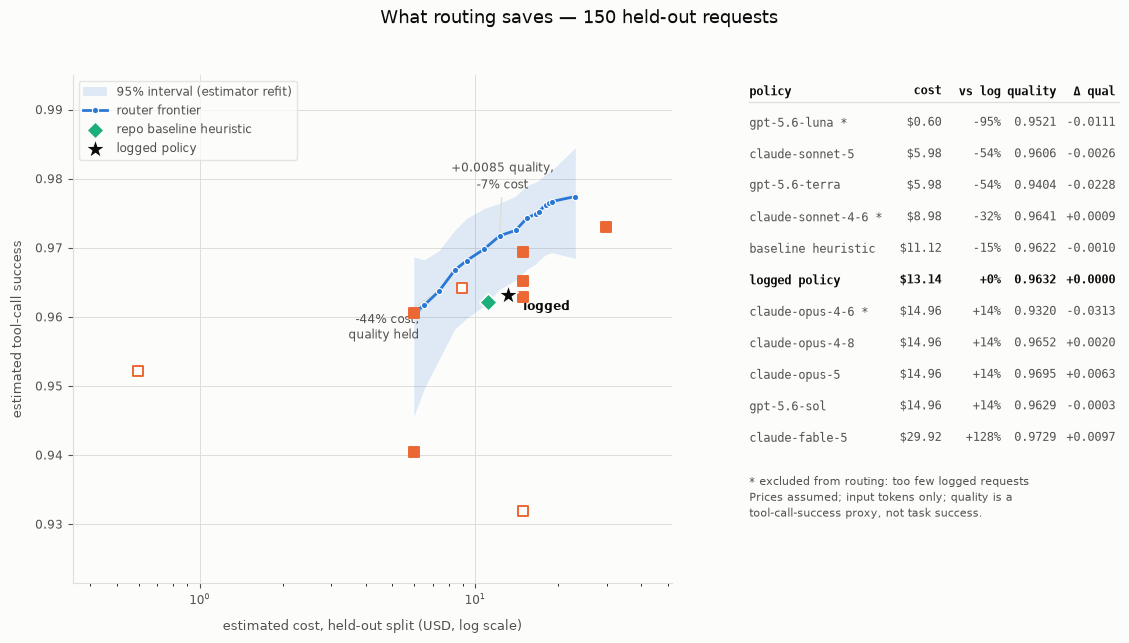

In [23]:
figure = plot_frontier(frontier, path=CONFIG.results_dir / 'frontier.png')

### 11.1 Which claims survive resampling

The interesting comparison is against the logged policy on each axis separately: hold quality
and read off the cost, or hold cost and read off the quality. The bootstrap below refits the
whole quality estimator on resampled training rows, so the interval answers "could this gap be
an artefact of who happened to serve what?" — which resampling the *evaluation* set cannot.

Read the CI column before the savings column. **Cost is arithmetic and solid; most of the
quality claims are not.**

In [24]:
logged = frontier['logged']
sweep = frontier['sweep']
uncertainty = frontier['quality_uncertainty']

iso_quality = min((r for r in sweep if r['mean_quality'] >= logged['mean_quality']),
                  key=lambda r: r['total_cost'])
iso_cost = max((r for r in sweep if r['total_cost'] <= logged['total_cost']),
               key=lambda r: r['mean_quality'])

rows = []
for label, row in (('logged policy', logged), ('same quality, cheaper', iso_quality),
                   ('same cost, better quality', iso_cost)):
    band = uncertainty.get(row['name'], {})
    rows.append({
        'policy': label,
        'cost_usd': round(row['total_cost'], 2),
        'vs_logged': f"{row['cost_vs_logged']:+.1%}",
        'est_quality': round(row['mean_quality'], 4),
        'quality_delta': f"{row['quality_vs_logged']:+.4f}",
        '95% CI on delta': (f"[{band['delta_vs_logged_lo']:+.4f}, {band['delta_vs_logged_hi']:+.4f}]"
                            if band else '—'),
        'survives': ('yes' if band.get('delta_excludes_zero') else 'no') if band else '—',
    })
print(format_metrics_table(rows))

print(f"\nCheapest routable point: ${min(r['total_cost'] for r in sweep):,.2f} "
      f"({min(sweep, key=lambda r: r['total_cost'])['cost_vs_logged']:+.1%} vs logged).")

# The number that looks best is the one with the least evidence behind it.
unrestricted = build_frontier(report, CONFIG, split='test', min_support=0, verbose=False)
cheapest = min(unrestricted['sweep'], key=lambda r: r['total_cost'])
print(f"\nWith the support floor removed, the cheapest router point becomes "
      f"${cheapest['total_cost']:,.2f} ({cheapest['cost_vs_logged']:+.1%}) by sending "
      f"{max(cheapest['mix'].values())}/{unrestricted['n_requests']} requests to "
      f"{max(cheapest['mix'], key=cheapest['mix'].get)}.")
print('That policy rests on 16 logged requests. It is in the notebook to be disbelieved.')

policy                     cost_usd  vs_logged  est_quality  quality_delta  95% CI on delta     survives
--------------------------------------------------------------------------------------------------------
logged policy              13.14     +0.0%      0.9632       +0.0000        [+0.0000, +0.0000]  no      
same quality, cheaper      7.38      -43.8%     0.9637       +0.0005        [-0.0080, +0.0067]  no      
same cost, better quality  12.28     -6.5%      0.9718       +0.0085        [+0.0021, +0.0139]  yes     

Cheapest routable point: $5.98 (-54.5% vs logged).

With the support floor removed, the cheapest router point becomes $0.60 (-95.4%) by sending 150/150 requests to gpt-5.6-luna.
That policy rests on 16 logged requests. It is in the notebook to be disbelieved.


### 11.2 Where this estimate can fail

Named rather than hidden, because the challenge scores it that way:

1. **The quality proxy barely moves.** Every model recovers ~94–97% of its tool calls; the whole
   spread is about three percentage points. A frontier built on it can rank models but says
   nothing about the failure that matters most — a confidently wrong answer that throws no tool
   error looks perfect here.
2. **The final output is missing.** The last call of every task is unscored by construction, and
   that is exactly where a task succeeds or fails.
3. **How you average changes the answer.** Pooling calls versus averaging per-request ratios
   reversed the ordering of two models (§10.1). Pooling is the defensible choice, but the fact
   that the ranking was ever that fragile is itself a warning about how thin the signal is.
4. **The benchmark catalog does not transfer** (§10.2), so §8's cutoffs carry no validated
   authority. The router avoids depending on them; anything that does inherits the problem.
5. **Positivity is thin at the edges.** Three of nine models are excluded outright, and several
   `(stratum, model)` cells rest on a few hundred calls. Shrinkage keeps those from exploding; it
   does not make them informative.
6. **Unconfoundedness is assumed, not established.** Near-zero correlation between complexity and
   the serving model makes matching plausible. If assignment depended on something unobserved
   that also drives tool errors — a customer tier, a time of day, a task type — the estimate is
   biased and nothing in this export would reveal it.
7. **Prices are invented and outputs uncounted.** Both cut the same way for every policy, so
   *relative* comparisons survive a wrong price sheet better than absolute dollars do — but a
   sheet with a different *ordering* would move the frontier itself.
8. **The router is not yet shown to beat a constant policy.** The frontier is compared against
   single-model baselines, but the permutation test — does the gain survive shuffling the
   predicted complexities? — has not been run. Until it is, "complexity-aware routing helps" is
   an open question, not a result.

## Files produced

| path | contents |
|---|---|
| `results/complexity_dataset/{split}_inputs.jsonl` | predictor-safe text and deterministic features |
| `results/complexity_dataset/{split}_targets.jsonl` | the score and its components |
| `results/complexity_dataset/{split}_metadata.jsonl` | audit-only identifiers and the logged model |
| `results/complexity_dataset/manifest.json` | formulas, scaling caps, split counts, limitations |
| `results/complexity_model/report.json` | metrics, head selection, timings, config |
| `results/complexity_model/predictions.json` | predicted score per request id |
| `results/complexity_model/complexity_model.png` | the four-panel model summary from section 6 |
| `results/complexity_model/frontier.json` | every policy's cost, estimated quality and interval |
| `results/complexity_model/frontier.png` | the cost–quality frontier from section 11 |
| `results/embedding_cache/*.npy` | pooled embeddings, keyed by settings + chunk text |

Everything under `results/` is gitignored, as is the export itself.

### Before quoting any of this

The cost figures assume `scripts/pricing.json`, count input tokens only, and estimate those
tokens as `chars/4`. The quality figures are a tool-call-success proxy recovered from partial
traces, not measured task success. Both are stated that way in section 11.2 — carry the caveats
with the numbers, not in a footnote.

The complexity score itself is weak supervision. Before using it as a router target, review a
stratified sample from the low/medium/high bands by hand: the score is auditable, but its
weights still encode assumptions that deserve validation against human or judge-model ratings.